# CBOW FROM SCRATCH: FULL TRAINING LOOP WITH BACKPROPAGATION


In [12]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=6, suppress=True)


# STEP 1: Define corpus


In [2]:
sentence = "I like orange juice and eat eggs daily"
tokens = sentence.split()

# Vocabulary
vocabulary = list(dict.fromkeys(tokens))
V = len(vocabulary)          # vocabulary size
N = 3                        # embedding dimension

word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for i, word in enumerate(vocabulary)}

print("STEP 1: Vocabulary")
print("Vocabulary:", vocabulary)
print("Vocabulary size V =", V)
print("Embedding dimension N =", N)

STEP 1: Vocabulary
Vocabulary: ['I', 'like', 'orange', 'juice', 'and', 'eat', 'eggs', 'daily']
Vocabulary size V = 8
Embedding dimension N = 3


# STEP 2: Utility functions


In [3]:
def one_hot(word, vocab_size, mapping):
    vec = np.zeros(vocab_size)
    vec[mapping[word]] = 1.0
    return vec

def softmax(x):
    shifted = x - np.max(x)
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x)

def get_context_words(tokens, target_index, window_size=2):
    start = max(0, target_index - window_size)
    end = min(len(tokens), target_index + window_size + 1)
    context = []
    for i in range(start, end):
        if i != target_index:
            context.append(tokens[i])
    return context

# STEP 3: Generate CBOW training data from the corpus


In [4]:
window_size = 2
training_data = []

for target_index, target_word in enumerate(tokens):
    context_words = get_context_words(tokens, target_index, window_size=window_size)
    training_data.append((context_words, target_word))

print("STEP 3: Generated CBOW Training Samples")
for i, (context_words, target_word) in enumerate(training_data, start=1):
    print(f"{i:>2}. Context = {context_words} -> Target = {target_word}")

STEP 3: Generated CBOW Training Samples
 1. Context = ['like', 'orange'] -> Target = I
 2. Context = ['I', 'orange', 'juice'] -> Target = like
 3. Context = ['I', 'like', 'juice', 'and'] -> Target = orange
 4. Context = ['like', 'orange', 'and', 'eat'] -> Target = juice
 5. Context = ['orange', 'juice', 'eat', 'eggs'] -> Target = and
 6. Context = ['juice', 'and', 'eggs', 'daily'] -> Target = eat
 7. Context = ['and', 'eat', 'daily'] -> Target = eggs
 8. Context = ['eat', 'eggs'] -> Target = daily


# STEP 4: Initialize weights
## W       : input-to-hidden  (V x N)
## W_prime : hidden-to-output (N x V)


In [5]:
np.random.seed(42)
W = np.random.randn(V, N) * 0.01
W_prime = np.random.randn(N, V) * 0.01

print("STEP 4: Initial Weight Matrices")
print("W shape:", W.shape)
print(pd.DataFrame(W, index=vocabulary, columns=[f"e{i+1}" for i in range(N)]))
print()
print("W_prime shape:", W_prime.shape)
print(pd.DataFrame(W_prime, index=[f"e{i+1}" for i in range(N)], columns=vocabulary))

STEP 4: Initial Weight Matrices
W shape: (8, 3)
              e1        e2        e3
I       0.004967 -0.001383  0.006477
like    0.015230 -0.002342 -0.002341
orange  0.015792  0.007674 -0.004695
juice   0.005426 -0.004634 -0.004657
and     0.002420 -0.019133 -0.017249
eat    -0.005623 -0.010128  0.003142
eggs   -0.009080 -0.014123  0.014656
daily  -0.002258  0.000675 -0.014247

W_prime shape: (3, 8)
           I      like    orange     juice       and       eat      eggs  \
e1 -0.005444  0.001109 -0.011510  0.003757 -0.006006 -0.002917 -0.006017   
e2 -0.000135 -0.010577  0.008225 -0.012208  0.002089 -0.019597 -0.013282   
e3  0.007385  0.001714 -0.001156 -0.003011 -0.014785 -0.007198 -0.004606   

       daily  
e1  0.018523  
e2  0.001969  
e3  0.010571  


# STEP 5: Training hyperparameters


In [6]:
learning_rate = 0.05
epochs = 500

print("STEP 5: Training Hyperparameters")
print("Learning rate =", learning_rate)
print("Epochs =", epochs)

STEP 5: Training Hyperparameters
Learning rate = 0.05
Epochs = 500


# STEP 6: Forward pass for one sample

In [7]:
def forward_pass(context_words, target_word, W, W_prime, word_to_index, V):
    # One-hot vectors for context words
    context_one_hots = [one_hot(word, V, word_to_index) for word in context_words]

    # Lookup embeddings using one-hot @ W
    context_embeddings = np.array([x @ W for x in context_one_hots])     # shape = (C, N)

    # Hidden vector = average of context embeddings
    h = np.mean(context_embeddings, axis=0)                              # shape = (N,)

    # Output scores
    scores = h @ W_prime                                                 # shape = (V,)

    # Softmax probabilities
    probabilities = softmax(scores)                                      # shape = (V,)

    # Target vector
    target_one_hot = one_hot(target_word, V, word_to_index)              # shape = (V,)

    # Cross-entropy loss
    loss = -np.log(probabilities[word_to_index[target_word]] + 1e-12)

    cache = {
        "context_words": context_words,
        "context_one_hots": context_one_hots,
        "context_embeddings": context_embeddings,
        "h": h,
        "scores": scores,
        "probabilities": probabilities,
        "target_one_hot": target_one_hot,
        "target_word": target_word,
    }

    return loss, cache

# STEP 7: Backpropagation for one sample

In [8]:
def backward_pass(cache, W, W_prime, learning_rate):
    context_one_hots = cache["context_one_hots"]
    h = cache["h"]
    probabilities = cache["probabilities"]
    target_one_hot = cache["target_one_hot"]

    C = len(context_one_hots)   # number of context words

    # Gradient at output layer
    d_scores = probabilities - target_one_hot                           # shape = (V,)

    # Gradient for W_prime
    dW_prime = np.outer(h, d_scores)                                    # shape = (N, V)

    # Gradient wrt hidden vector
    dh = W_prime @ d_scores                                             # shape = (N,)

    # Because h is the average of context embeddings,
    # each context embedding receives dh / C
    d_context_embedding = dh / C                                        # shape = (N,)

    # Gradient for W
    dW = np.zeros_like(W)                                               # shape = (V, N)

    for x in context_one_hots:
        dW += np.outer(x, d_context_embedding)

    # Gradient descent update
    W -= learning_rate * dW
    W_prime -= learning_rate * dW_prime

    return W, W_prime

# STEP 8: Training loop


STEP 8: Training Starts
Epoch   1 | Average Loss = 0.003787
Epoch  50 | Average Loss = 0.003617
Epoch 100 | Average Loss = 0.003457
Epoch 150 | Average Loss = 0.003310
Epoch 200 | Average Loss = 0.003174
Epoch 250 | Average Loss = 0.003048
Epoch 300 | Average Loss = 0.002931
Epoch 350 | Average Loss = 0.002822
Epoch 400 | Average Loss = 0.002721
Epoch 450 | Average Loss = 0.002626
Epoch 500 | Average Loss = 0.002537


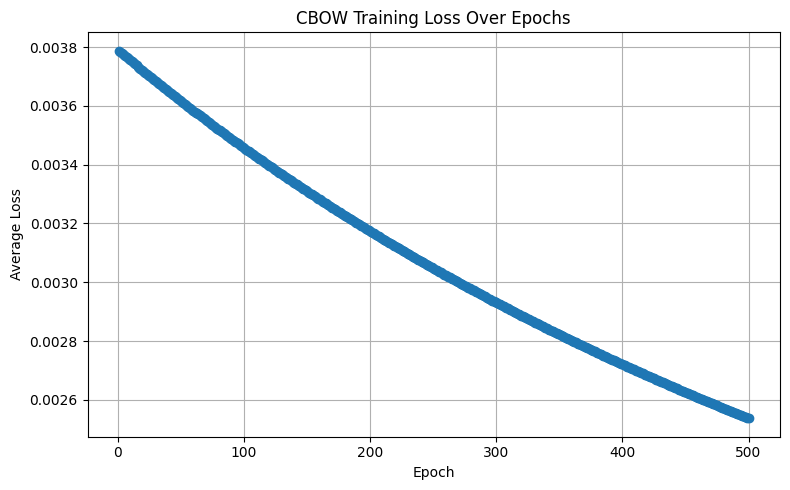

In [15]:
loss_history = []

print("STEP 8: Training Starts")
for epoch in range(1, epochs + 1):
    total_loss = 0.0

    for context_words, target_word in training_data:
        loss, cache = forward_pass(context_words, target_word, W, W_prime, word_to_index, V)
        total_loss += loss

        W, W_prime = backward_pass(cache, W, W_prime, learning_rate)

    avg_loss = total_loss / len(training_data)
    loss_history.append(avg_loss)

    if epoch == 1 or epoch % 50 == 0 or epoch == epochs:
        print(f"Epoch {epoch:>3} | Average Loss = {avg_loss:.6f}")

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Plot Loss Curve
# ------------------------------------------------------------
epochs_range = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs_range, loss_history, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("CBOW Training Loss Over Epochs")

plt.grid(True)

plt.tight_layout()
plt.show()

# STEP 9: Show final learned embeddings

In [10]:
print("STEP 9: Learned Embeddings (W)")
embedding_df = pd.DataFrame(W, index=vocabulary, columns=[f"e{i+1}" for i in range(N)])
print(embedding_df)

STEP 9: Learned Embeddings (W)
              e1        e2        e3
I      -0.776175  1.571861 -1.800015
like    3.049947  0.936917 -1.104912
orange  2.089936  3.063020  2.070842
juice  -2.483275  2.454031 -0.579645
and     0.100715 -2.250619 -3.495998
eat     1.080477 -3.307310  1.797440
eggs   -2.131605 -0.805806  2.605160
daily  -1.459711 -1.479583 -1.427361


# STEP 10: Test one training example after learning

In [11]:
test_context_words, test_target_word = training_data[2]   # Example sample
loss, cache = forward_pass(test_context_words, test_target_word, W, W_prime, word_to_index, V)

probabilities = cache["probabilities"]
scores = cache["scores"]
predicted_index = np.argmax(probabilities)
predicted_word = index_to_word[predicted_index]

print("STEP 10: Test After Training")
print("Context words:", test_context_words)
print("Actual target:", test_target_word)
print("Predicted word:", predicted_word)
print("Loss:", loss)
print()

result_df = pd.DataFrame({
    "Word": vocabulary,
    "Score": scores,
    "Probability": probabilities
}).sort_values(by="Probability", ascending=False).reset_index(drop=True)

print(result_df)

STEP 10: Test After Training
Context words: ['I', 'like', 'juice', 'and']
Actual target: orange
Predicted word: orange
Loss: 0.023402513815489835

     Word     Score  Probability
0  orange  6.783152     0.976869
1    like  2.492179     0.013375
2     eat  1.819370     0.006825
3   juice  0.075325     0.001193
4       I -0.233108     0.000876
5    eggs -0.262674     0.000851
6   daily -5.221282     0.000006
7     and -5.462887     0.000005


# STEP 11: Show all training examples with predictions

In [12]:
print("STEP 11: Final Predictions for All Training Samples")
rows = []

for context_words, target_word in training_data:
    loss, cache = forward_pass(context_words, target_word, W, W_prime, word_to_index, V)
    probabilities = cache["probabilities"]
    predicted_word = index_to_word[np.argmax(probabilities)]

    rows.append({
        "Context": ", ".join(context_words),
        "Target": target_word,
        "Predicted": predicted_word,
        "Loss": round(loss, 6)
    })

final_predictions_df = pd.DataFrame(rows)
print(final_predictions_df)

STEP 11: Final Predictions for All Training Samples
                    Context  Target Predicted      Loss
0              like, orange       I         I  0.021358
1          I, orange, juice    like      like  0.022419
2       I, like, juice, and  orange    orange  0.023403
3    like, orange, and, eat   juice     juice  0.047748
4  orange, juice, eat, eggs     and       and  0.044543
5   juice, and, eggs, daily     eat       eat  0.029569
6           and, eat, daily    eggs      eggs  0.019033
7                 eat, eggs   daily     daily  0.016409
